# Signal Audit — Backtest vs Bybit Live Trades

این نوت‌بوک:
1. **1000 کندل M5 + 300 کندل H1** آخر را از Bybit می‌گیرد و در `data/test/{SYMBOL}/` ذخیره می‌کند.
2. سیگنال‌ها، ترید‌ها و متریک‌ها را **دقیقاً مانند `03_strategy03_crypto_bybit.ipynb`** محاسبه می‌کند.
3. لیست **orders و trade های واقعی** را از Bybit می‌گیرد.
4. **مقایسه دقیق** می‌کند که آیا سیگنال‌های استراتژی به درستی شناسایی و در بایبیت اجرا شده‌اند یا نه.
5. هر **مغایرت** بین سیگنال‌های backtest و ترید های واقعی را گزارش می‌دهد.

In [85]:
# SECTION 1 — Imports and parameters
import warnings
warnings.filterwarnings("ignore")

import sys, os, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use("seaborn-v0_8-darkgrid")

# Resolve project root (notebooks/ -> parent)
_ROOT = Path.cwd().resolve()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

# Load .env
try:
    from dotenv import load_dotenv
    _env = _ROOT / ".env"
    if _env.exists():
        load_dotenv(_env)
        print(f"Loaded .env from {_env}")
except ImportError:
    pass

from strategy.crypto_core import EMA_FAST, EMA_MID, EMA_SLOW, default_crypto_tick

# ═══════════════════════════════════════════════════════
# USER PARAMETERS — same defaults as 03_strategy03_crypto_bybit.ipynb
# ═══════════════════════════════════════════════════════
SYMBOL             = "BTCUSDT"
TF_ENTRY           = "M5"
TF_TREND           = "H1"

LOOKBACK_BARS      = 5
PENDING_OFFSET_TICKS = 3.0
PENDING_EXPIRY_MIN = 60
RR                 = 1.0
PIP_SIZE           = default_crypto_tick(SYMBOL)
PENDING_OFFSET_PIPS = float(PENDING_OFFSET_TICKS)

START_BALANCE  = 10_000.0
RISK_PER_TRADE = 0.01

# ── کندل‌های دریافتی (1000 M5 + 300 H1) ──────────────────────────
BARS_M5 = 1000
BARS_H1 = 300

CATEGORY = "linear"
TESTNET  = os.getenv("BYBIT_TESTNET", "false").lower() == "true"
DEMO     = os.getenv("BYBIT_DEMO",    "false").lower() == "true"   # ← اضافه شد

BYBIT_INTERVAL_MAP = {
    "M1": "1",  "M3": "3",  "M5": "5",  "M15": "15", "M30": "30",
    "H1": "60", "H2": "120","H4": "240","H6": "360", "H12": "720",
    "D1": "D",  "W1": "W",  "MN": "M",
}

# ── مسیر ذخیره داده تست ───────────────────────────────────────────
TEST_DATA_DIR = _ROOT / "notebooks" / "data" / "test" / SYMBOL

_endpoint = "testnet" if TESTNET else ("demo" if DEMO else "mainnet")
print(f"Symbol={SYMBOL}  Trend={TF_TREND}  Entry={TF_ENTRY}")
print(f"PIP_SIZE={PIP_SIZE}  offset_ticks={PENDING_OFFSET_TICKS}")
print(f"Bybit endpoint: {_endpoint}  (TESTNET={TESTNET}  DEMO={DEMO})")
print(f"Test data dir : {TEST_DATA_DIR}")

Loaded .env from D:\bot\ema-h1trend-exchange\.env
Symbol=BTCUSDT  Trend=H1  Entry=M5
PIP_SIZE=1.0  offset_ticks=3.0
Bybit endpoint: demo  (TESTNET=False  DEMO=True)
Test data dir : D:\bot\ema-h1trend-exchange\notebooks\data\test\BTCUSDT


In [86]:
# SECTION 2 — Fetch 1000 M5 + 300 H1 candles from Bybit and save to data/test/SYMBOL/
from pybit.unified_trading import HTTP

api_key    = os.getenv("BYBIT_API_KEY", "")
api_secret = os.getenv("BYBIT_API_SECRET", "")

# ── مهم: demo=DEMO برای اتصال به api-demo.bybit.com ──────────────
client = HTTP(
    testnet=TESTNET,
    demo=DEMO,
    api_key=api_key or None,
    api_secret=api_secret or None,
)
print(f"Bybit HTTP client ready  (demo={DEMO}, testnet={TESTNET})")
print(f"API key set: {bool(api_key)}")

_TEHRAN = "Asia/Tehran"


def fetch_klines(symbol: str, interval: str, limit: int) -> pd.DataFrame:
    """Fetch up to `limit` candles from Bybit with pagination."""
    all_rows = []
    end_time  = None
    remaining = limit

    while remaining > 0:
        batch  = min(remaining, 1000)
        kwargs = dict(category=CATEGORY, symbol=symbol, interval=interval, limit=batch)
        if end_time is not None:
            kwargs["end"] = end_time

        for attempt in range(1, 4):
            try:
                resp = client.get_kline(**kwargs)
                if resp.get("retCode") != 0:
                    raise RuntimeError(f"Bybit error {resp.get('retCode')}: {resp.get('retMsg')}")
                rows = resp["result"].get("list", [])
                break
            except Exception as exc:
                if attempt == 3:
                    raise
                time.sleep(2 ** attempt)

        if not rows:
            break
        all_rows.extend(rows)
        remaining -= len(rows)
        end_time = int(rows[-1][0]) - 1
        if len(rows) < batch:
            break
        time.sleep(0.05)

    df = pd.DataFrame(
        list(reversed(all_rows)),
        columns=["time", "open", "high", "low", "close", "volume", "turnover"],
    )
    df["time"] = pd.to_datetime(df["time"].astype("int64"), unit="ms", utc=True)
    df = df.set_index("time").sort_index()
    df = df[~df.index.duplicated(keep="last")]
    for col in ["open", "high", "low", "close", "volume"]:
        df[col] = df[col].astype(float)
    if len(df) > 0:
        df = df.iloc[:-1]  # drop forming candle
    df.index = df.index.tz_convert(_TEHRAN)
    return df[["open", "high", "low", "close", "volume"]]


# Fetch M5
print(f"\nFetching {BARS_M5} {TF_ENTRY} candles for {SYMBOL}...")
m5_raw = fetch_klines(SYMBOL, BYBIT_INTERVAL_MAP[TF_ENTRY], BARS_M5)
(TEST_DATA_DIR / TF_ENTRY).mkdir(parents=True, exist_ok=True)
m5_raw.to_csv(TEST_DATA_DIR / TF_ENTRY / "ohlcv.csv")
print(f"  -> {len(m5_raw):,} rows | {m5_raw.index[0]} → {m5_raw.index[-1]}")

# Fetch H1
print(f"Fetching {BARS_H1} {TF_TREND} candles for {SYMBOL}...")
h1_raw = fetch_klines(SYMBOL, BYBIT_INTERVAL_MAP[TF_TREND], BARS_H1)
(TEST_DATA_DIR / TF_TREND).mkdir(parents=True, exist_ok=True)
h1_raw.to_csv(TEST_DATA_DIR / TF_TREND / "ohlcv.csv")
print(f"  -> {len(h1_raw):,} rows | {h1_raw.index[0]} → {h1_raw.index[-1]}")

# Keep copies for strategy
m5 = m5_raw.copy()
h1 = h1_raw.copy()

print(f"\nSaved to: {TEST_DATA_DIR}")
display(m5.tail(3))
display(h1.tail(3))

Bybit HTTP client ready  (demo=True, testnet=False)
API key set: True

Fetching 1000 M5 candles for BTCUSDT...
  -> 999 rows | 2026-05-10 06:45:00+03:30 → 2026-05-13 17:55:00+03:30
Fetching 300 H1 candles for BTCUSDT...
  -> 299 rows | 2026-05-01 06:30:00+03:30 → 2026-05-13 16:30:00+03:30

Saved to: D:\bot\ema-h1trend-exchange\notebooks\data\test\BTCUSDT


,open,high,low,close,volume
time,,,,,
2026-05-13 17:45:00+03:30,79664.1,79731.5,79611.8,79666.4,470.602
2026-05-13 17:50:00+03:30,79666.4,79775.3,79633.1,79736.1,272.993
2026-05-13 17:55:00+03:30,79736.1,79857.8,79728.0,79807.2,420.847


,open,high,low,close,volume
time,,,,,
2026-05-13 14:30:00+03:30,80774.2,80818.5,80456.1,80460.1,2497.178
2026-05-13 15:30:00+03:30,80460.1,80560.0,79804.3,80150.0,6901.069
2026-05-13 16:30:00+03:30,80150.0,80304.6,79525.0,79605.9,6047.340


In [87]:
# SECTION 3 — EMA 8/13/21 on both timeframes (identical to notebook 03)
from strategy.crypto_core import add_emas

m5 = add_emas(m5)
h1 = add_emas(h1)

print("EMA columns added.")
display(h1[[f"ema_{EMA_FAST}", f"ema_{EMA_MID}", f"ema_{EMA_SLOW}"]].tail(5))

EMA columns added.


,ema_8,ema_13,ema_21
time,,,
2026-05-13 12:30:00+03:30,81055.126161,80977.142026,80926.117754
2026-05-13 13:30:00+03:30,80992.698125,80948.150308,80912.307049
2026-05-13 14:30:00+03:30,80874.342986,80878.428835,80871.197317
2026-05-13 15:30:00+03:30,80713.377878,80774.367573,80805.633925
2026-05-13 16:30:00+03:30,80467.271683,80607.443634,80696.567204


In [88]:
# SECTION 4 — Merge H1 trend onto M5 (identical to notebook 03)
from strategy.crypto_core import merge_h1_trend_onto_m5

m5_ctx = merge_h1_trend_onto_m5(m5, h1)

print(m5_ctx["trend"].value_counts(dropna=False))
display(m5_ctx[["close", "trend"]].tail(8))

trend
bull    441
bear    306
flat    252
Name: count, dtype: int64


,close,trend
time,,
2026-05-13 17:20:00+03:30,79705.9,bear
2026-05-13 17:25:00+03:30,79605.9,bear
2026-05-13 17:30:00+03:30,79600.0,bear
2026-05-13 17:35:00+03:30,79639.1,bear
2026-05-13 17:40:00+03:30,79664.1,bear
2026-05-13 17:45:00+03:30,79666.4,bear
2026-05-13 17:50:00+03:30,79736.1,bear
2026-05-13 17:55:00+03:30,79807.2,bear


In [89]:
# SECTION 5 — Run backtest (identical to notebook 03)
from strategy.backtest import run_backtest

trades_df, equity_curve = run_backtest(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
    pending_expiry_min=PENDING_EXPIRY_MIN,
    entry_timeframe_minutes=5,
)
print(f"Total backtest trades: {len(trades_df)}")
display(trades_df.tail(10))

Total backtest trades: 26


,entry_time,exit_time,side,entry,sl,tp,exit,qty,pnl,balance_after,result
16,2026-05-12 18:50:00+03:30,2026-05-12 20:15:00+03:30,sell,80377.0,80857.6,79896.4,79896.4,0.001244,0.597960,10001.063727,win
17,2026-05-13 00:00:00+03:30,2026-05-13 01:00:00+03:30,sell,80676.2,80833.0,80519.4,80519.4,0.001240,0.194378,10001.258105,win
18,2026-05-13 01:10:00+03:30,2026-05-13 01:30:00+03:30,sell,80512.3,80691.1,80333.5,80691.1,0.001242,-0.222106,10001.035999,loss
19,2026-05-13 02:45:00+03:30,2026-05-13 03:05:00+03:30,sell,80575.4,80690.9,80459.9,80459.9,0.001241,0.143359,10001.179358,win
20,2026-05-13 03:15:00+03:30,2026-05-13 03:50:00+03:30,sell,80428.1,80634.6,80221.6,80634.6,0.001243,-0.256781,10000.922576,loss
21,2026-05-13 09:45:00+03:30,2026-05-13 10:20:00+03:30,buy,81065.0,80959.2,81170.8,80959.2,0.001234,-0.130525,10000.792052,loss
22,2026-05-13 11:35:00+03:30,2026-05-13 12:15:00+03:30,buy,80999.6,80862.0,81137.2,81137.2,0.001235,0.169891,10000.961943,win
23,2026-05-13 12:25:00+03:30,2026-05-13 14:00:00+03:30,buy,81153.0,80901.3,81404.7,80901.3,0.001232,-0.310185,10000.651758,loss
24,2026-05-13 15:40:00+03:30,2026-05-13 15:50:00+03:30,sell,80453.1,80671.0,80235.2,80235.2,0.001243,0.270859,10000.922616,win
25,2026-05-13 16:00:00+03:30,2026-05-13 17:15:00+03:30,sell,80132.0,80563.0,79701.0,79701.0,0.001248,0.537912,10001.460529,win


In [90]:
# SECTION 5b — Signals and entry fills (identical to notebook 03)
from strategy.setup import list_setup_signals, list_trade_entries

entry_signals_df = list_setup_signals(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
)
entry_fills_df = list_trade_entries(
    m5_ctx,
    start_balance=START_BALANCE,
    lookback_bars=LOOKBACK_BARS,
    pending_offset_ticks=PENDING_OFFSET_PIPS,
    pip_size=PIP_SIZE,
    rr=RR,
    risk_per_trade=RISK_PER_TRADE,
    pending_expiry_min=PENDING_EXPIRY_MIN,
    entry_timeframe_minutes=5,
)

print(f"Signals (setup bars) : {len(entry_signals_df)}")
print(f"Fills (triggered)    : {len(entry_fills_df)}")

RESULT_DIR = Path("./results") / "audit" / SYMBOL / TF_ENTRY
RESULT_DIR.mkdir(parents=True, exist_ok=True)
entry_signals_df.to_csv(RESULT_DIR / "backtest_signals.csv", index=False)
entry_fills_df.to_csv(RESULT_DIR / "backtest_fills.csv", index=False)

print(f"\nSaved backtest signals/fills -> {RESULT_DIR}")
display(entry_fills_df.tail(10))

Signals (setup bars) : 742
Fills (triggered)    : 27

Saved backtest signals/fills -> results\audit\BTCUSDT\M5


,signal_bar_time,signal_bar_index,entry_time,entry_bar_index,side,entry,sl,tp,qty
17,2026-05-12 23:30:00+03:30,777,2026-05-13 00:00:00+03:30,783,sell,80676.2,80833.0,80519.4,0.001240
18,2026-05-13 01:05:00+03:30,796,2026-05-13 01:10:00+03:30,797,sell,80512.3,80691.1,80333.5,0.001242
19,2026-05-13 02:40:00+03:30,815,2026-05-13 02:45:00+03:30,816,sell,80575.4,80690.9,80459.9,0.001241
20,2026-05-13 03:10:00+03:30,821,2026-05-13 03:15:00+03:30,822,sell,80428.1,80634.6,80221.6,0.001243
21,2026-05-13 09:40:00+03:30,899,2026-05-13 09:45:00+03:30,900,buy,81065.0,80959.2,81170.8,0.001234
22,2026-05-13 11:30:00+03:30,921,2026-05-13 11:35:00+03:30,922,buy,80999.6,80862.0,81137.2,0.001235
23,2026-05-13 12:20:00+03:30,931,2026-05-13 12:25:00+03:30,932,buy,81153.0,80901.3,81404.7,0.001232
24,2026-05-13 15:30:00+03:30,969,2026-05-13 15:40:00+03:30,971,sell,80453.1,80671.0,80235.2,0.001243
25,2026-05-13 15:55:00+03:30,974,2026-05-13 16:00:00+03:30,975,sell,80132.0,80563.0,79701.0,0.001248
26,2026-05-13 17:20:00+03:30,991,2026-05-13 17:30:00+03:30,993,sell,79522.0,80191.5,78852.5,0.001258


In [91]:
# SECTION 6 — Metrics (identical to notebook 03)
def max_drawdown_pct(equity) -> float:
    if equity is None or len(equity) < 2:
        return 0.0
    eq   = pd.Series(equity).astype(float).dropna()
    peak = eq.cummax()
    dd   = (eq - peak) / peak.replace(0, np.nan)
    return float(abs(dd.min()) * 100.0)


def summarize_results(trades: pd.DataFrame, start_balance: float, equity=None) -> pd.DataFrame:
    if trades.empty:
        return pd.DataFrame([{"trades": 0, "win_rate_%": 0.0, "net_pnl": 0.0,
                               "profit_factor": 0.0, "max_drawdown_%": round(max_drawdown_pct(equity), 2),
                               "start_balance": start_balance, "end_balance": start_balance, "return_%": 0.0}])
    wins   = trades[trades["pnl"] > 0]["pnl"]
    losses = trades[trades["pnl"] < 0]["pnl"]
    gp     = wins.sum() if not wins.empty else 0.0
    gl     = abs(losses.sum()) if not losses.empty else 0.0
    pf     = gp / gl if gl > 0 else np.nan
    end_b  = float(trades["balance_after"].iloc[-1])
    return pd.DataFrame([{
        "trades":          int(len(trades)),
        "win_rate_%":      round((trades["pnl"] > 0).mean() * 100, 2),
        "net_pnl":         round(trades["pnl"].sum(), 2),
        "avg_pnl":         round(trades["pnl"].mean(), 2),
        "profit_factor":   round(float(pf), 3) if pd.notna(pf) else np.nan,
        "max_drawdown_%":  round(max_drawdown_pct(equity), 2),
        "start_balance":   round(start_balance, 2),
        "end_balance":     round(end_b, 2),
        "return_%":        round(((end_b / start_balance) - 1) * 100, 2),
    }])


if not trades_df.empty:
    trades_df = trades_df.copy()
    trades_df["exit_minus_entry"] = trades_df["exit"] - trades_df["entry"]
    trades_df["cumulative_pnl"]   = trades_df["pnl"].cumsum()

summary = summarize_results(trades_df, START_BALANCE, equity_curve)
display(summary)
summary.to_csv(RESULT_DIR / "backtest_metrics.csv", index=False)

,trades,win_rate_%,net_pnl,avg_pnl,profit_factor,max_drawdown_%,start_balance,end_balance,return_%
0,26,61.54,1.46,0.06,1.362,0.02,10000.0,10001.46,0.01


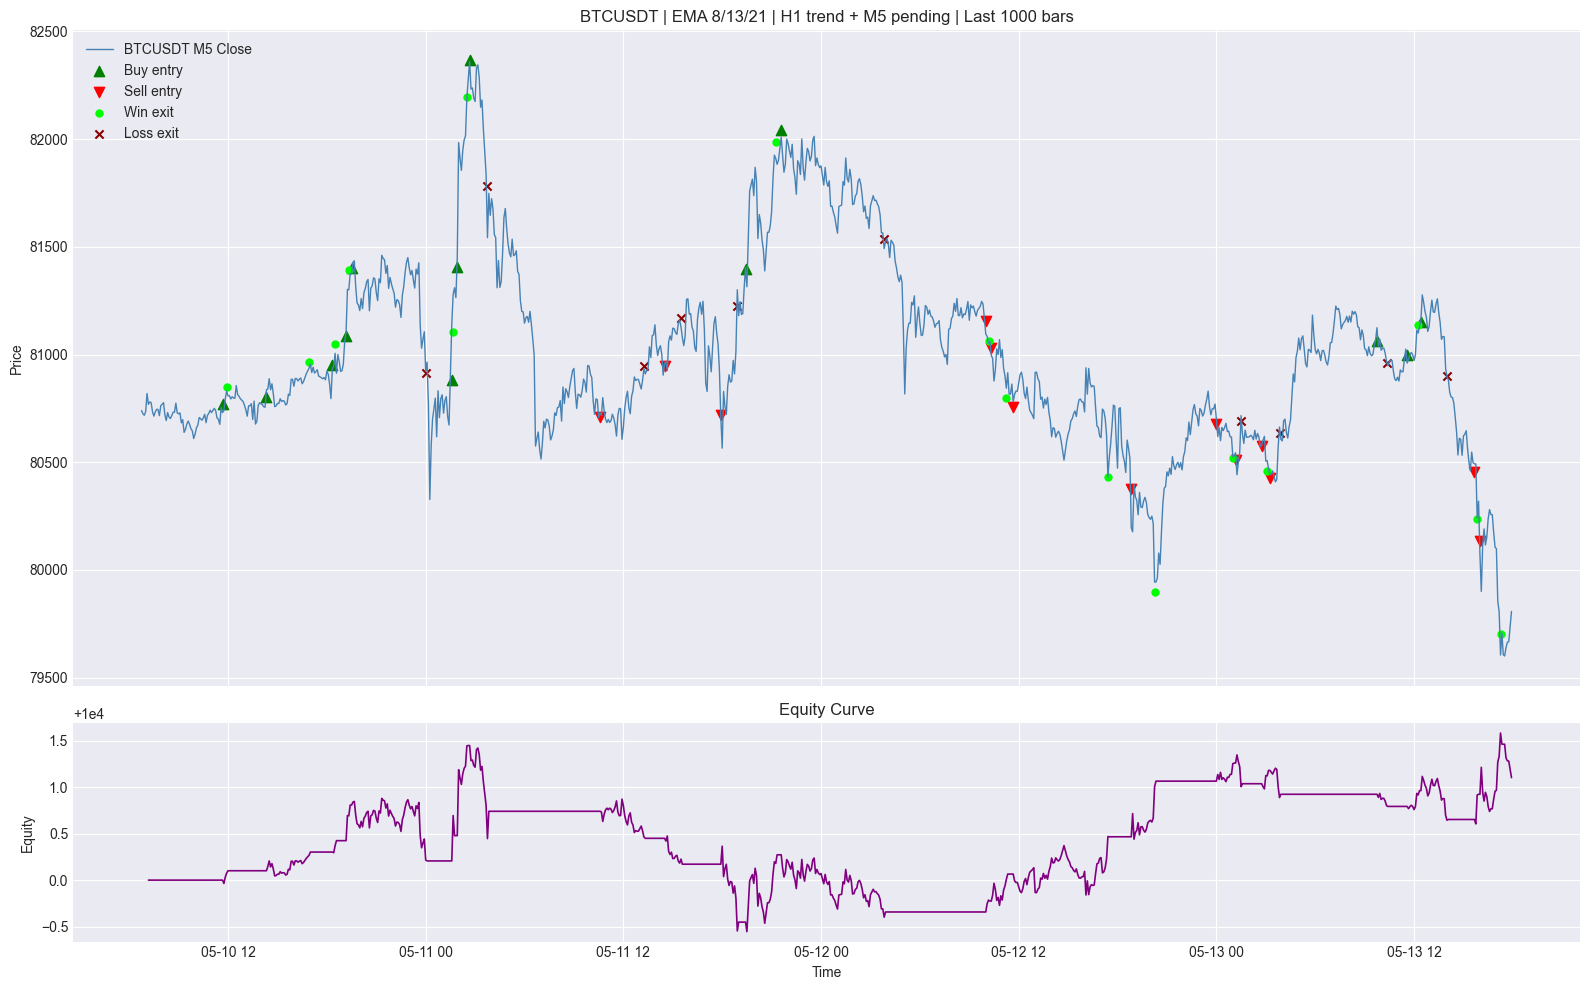

In [92]:
# SECTION 7 — Chart (identical to notebook 03)
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
ax_price, ax_eq = axes

ax_price.plot(m5_ctx.index, m5_ctx["close"],
              label=f"{SYMBOL} M5 Close", color="steelblue", linewidth=1.0)

if not trades_df.empty:
    buys  = trades_df[trades_df["side"] == "buy"]
    sells = trades_df[trades_df["side"] == "sell"]
    ax_price.scatter(buys["entry_time"],  buys["entry"],  marker="^", color="green",   s=55, label="Buy entry")
    ax_price.scatter(sells["entry_time"], sells["entry"], marker="v", color="red",     s=55, label="Sell entry")
    ax_price.scatter(trades_df[trades_df["pnl"] > 0]["exit_time"],
                     trades_df[trades_df["pnl"] > 0]["exit"],
                     marker="o", color="lime", s=25, label="Win exit")
    ax_price.scatter(trades_df[trades_df["pnl"] <= 0]["exit_time"],
                     trades_df[trades_df["pnl"] <= 0]["exit"],
                     marker="x", color="darkred", s=35, label="Loss exit")

ax_price.set_title(f"{SYMBOL} | EMA {EMA_FAST}/{EMA_MID}/{EMA_SLOW} | H1 trend + M5 pending | Last {BARS_M5} bars")
ax_price.set_ylabel("Price")
ax_price.legend(loc="upper left")

if equity_curve is not None and len(equity_curve) > 0:
    ax_eq.plot(equity_curve.index, equity_curve.values, color="purple", linewidth=1.2)
ax_eq.set_title("Equity Curve")
ax_eq.set_ylabel("Equity")
ax_eq.set_xlabel("Time")

plt.tight_layout()
plt.savefig(RESULT_DIR / "backtest_chart.png", dpi=120)
plt.show()

In [93]:
# SECTION 8 — Save backtest trades
if trades_df is None or trades_df.empty:
    pd.DataFrame(columns=[
        "entry_time","exit_time","side","entry","sl","tp","exit",
        "qty","pnl","balance_after","result","exit_minus_entry","cumulative_pnl"
    ]).to_csv(RESULT_DIR / "backtest_trades.csv", index=False)
else:
    trades_df.to_csv(RESULT_DIR / "backtest_trades.csv", index=False)

print(f"Saved backtest results -> {RESULT_DIR}")

Saved backtest results -> results\audit\BTCUSDT\M5


---
## SECTION 9 — Fetch Actual Orders & Trades from Bybit

در این بخش، ترید‌ها و اوردرهای واقعی که در Bybit ثبت شده‌اند را برای بازه زمانی 1000 کندل M5 آخر دریافت می‌کنیم.

In [94]:
# SECTION 9a — تعیین بازه زمانی بر اساس داده M5
# تبدیل به UTC برای API Bybit
m5_utc = m5_raw.copy()
m5_utc.index = m5_utc.index.tz_convert("UTC")

DATA_START_UTC = m5_utc.index[0]
DATA_END_UTC   = m5_utc.index[-1]

START_MS = int(DATA_START_UTC.timestamp() * 1000)
END_MS   = int(DATA_END_UTC.timestamp() * 1000) + 5 * 60 * 1000  # +1 bar buffer

print(f"Data window (UTC): {DATA_START_UTC} → {DATA_END_UTC}")
print(f"Start ms: {START_MS}")
print(f"End ms  : {END_MS}")

Data window (UTC): 2026-05-10 03:15:00+00:00 → 2026-05-13 14:25:00+00:00
Start ms: 1778382900000
End ms  : 1778682600000


In [95]:
# SECTION 9b — Order History (همه اوردرهای ثبت شده در Bybit)

def fetch_order_history(symbol: str, start_ms: int, end_ms: int, limit: int = 50) -> pd.DataFrame:
    """همه اوردرهای تاریخی (Filled + Cancelled + Rejected) را با pagination می‌گیرد."""
    all_orders = []
    cursor = None
    MAX_PAGES = 20

    for page in range(MAX_PAGES):
        kwargs = dict(
            category=CATEGORY,
            symbol=symbol,
            limit=min(limit, 50),
            startTime=str(start_ms),
            endTime=str(end_ms),
            orderFilter="Order",  # نرمال و conditional
        )
        if cursor:
            kwargs["cursor"] = cursor

        try:
            resp = client.get_order_history(**kwargs)
            if resp.get("retCode") != 0:
                print(f"  Warning: {resp.get('retMsg')}")
                break
            result = resp["result"]
            items = result.get("list", [])
            all_orders.extend(items)
            cursor = result.get("nextPageCursor", "")
            if not cursor or not items:
                break
            time.sleep(0.1)
        except Exception as exc:
            print(f"  Error fetching order history: {exc}")
            break

    if not all_orders:
        return pd.DataFrame()

    df = pd.DataFrame(all_orders)
    # زمان‌ها را parse کنیم
    for col in ["createdTime", "updatedTime"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col].astype("int64"), unit="ms", utc=True).dt.tz_convert(_TEHRAN)
    for col in ["price", "qty", "triggerPrice", "avgPrice", "cumExecQty", "leavesQty",
                "stopLoss", "takeProfit"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def fetch_stop_order_history(symbol: str, start_ms: int, end_ms: int, limit: int = 50) -> pd.DataFrame:
    """اوردرهای Stop/Conditional تاریخی."""
    all_orders = []
    cursor = None
    MAX_PAGES = 20

    for page in range(MAX_PAGES):
        kwargs = dict(
            category=CATEGORY,
            symbol=symbol,
            limit=min(limit, 50),
            startTime=str(start_ms),
            endTime=str(end_ms),
            orderFilter="StopOrder",
        )
        if cursor:
            kwargs["cursor"] = cursor

        try:
            resp = client.get_order_history(**kwargs)
            if resp.get("retCode") != 0:
                print(f"  Warning StopOrder: {resp.get('retMsg')}")
                break
            result = resp["result"]
            items = result.get("list", [])
            all_orders.extend(items)
            cursor = result.get("nextPageCursor", "")
            if not cursor or not items:
                break
            time.sleep(0.1)
        except Exception as exc:
            print(f"  Error fetching stop order history: {exc}")
            break

    if not all_orders:
        return pd.DataFrame()

    df = pd.DataFrame(all_orders)
    for col in ["createdTime", "updatedTime"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col].astype("int64"), unit="ms", utc=True).dt.tz_convert(_TEHRAN)
    for col in ["price", "qty", "triggerPrice", "avgPrice", "cumExecQty", "leavesQty",
                "stopLoss", "takeProfit"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


print(f"Fetching order history for {SYMBOL}...")
bybit_orders_df = fetch_order_history(SYMBOL, START_MS, END_MS)
print(f"  Normal orders: {len(bybit_orders_df)}")

print(f"Fetching stop/conditional order history...")
bybit_stop_orders_df = fetch_stop_order_history(SYMBOL, START_MS, END_MS)
print(f"  Stop orders: {len(bybit_stop_orders_df)}")

# نمایش ستون‌های مهم
key_cols_order = [c for c in ["orderLinkId", "side", "orderType", "triggerPrice", "price",
                               "qty", "stopLoss", "takeProfit", "orderStatus",
                               "createdTime", "updatedTime"] if c in bybit_stop_orders_df.columns]

print("\n--- Stop Orders (tail) ---")
if not bybit_stop_orders_df.empty:
    display(bybit_stop_orders_df[key_cols_order].tail(20))
else:
    print("  هیچ stop order ای در این بازه زمانی ثبت نشده.")

Fetching order history for BTCUSDT...
  Normal orders: 0
Fetching stop/conditional order history...
  Stop orders: 5

--- Stop Orders (tail) ---


,orderLinkId,side,orderType,triggerPrice,price,qty,stopLoss,takeProfit,orderStatus,createdTime,updatedTime
0,ema-15316363-s-1778680200,Sell,Limit,79522.0,79522.0,0.007,80178.7,78865.3,Filled,2026-05-13 17:25:02.738000+03:30,2026-05-13 17:30:14.326000+03:30
1,,Buy,Market,79860.4,80674.9,0.007,NaN,NaN,Filled,2026-05-13 17:00:03.155000+03:30,2026-05-13 17:09:34.616000+03:30
2,,Buy,Market,80307.6,0.0,0.007,NaN,NaN,Deactivated,2026-05-13 17:00:03.155000+03:30,2026-05-13 17:09:34.616000+03:30
3,ema-15316363-s-1778676900,Sell,Limit,80084.0,80084.0,0.007,80307.6,79860.4,Filled,2026-05-13 16:30:03.931000+03:30,2026-05-13 17:00:03.155000+03:30
4,ema-15316363-b-1778665500,Buy,Limit,81085.0,81085.0,0.007,80767.0,81403.0,Deactivated,2026-05-13 13:23:20.582000+03:30,2026-05-13 14:30:03.487000+03:30


In [96]:
# SECTION 9c — Closed P&L (تریدهای بسته شده)

def fetch_closed_pnl(symbol: str, start_ms: int, end_ms: int) -> pd.DataFrame:
    """تمام تریدهای closed را با P&L می‌گیرد."""
    all_pnl = []
    cursor  = None
    MAX_PAGES = 20

    for page in range(MAX_PAGES):
        kwargs = dict(
            category=CATEGORY,
            symbol=symbol,
            limit=100,
            startTime=str(start_ms),
            endTime=str(end_ms),
        )
        if cursor:
            kwargs["cursor"] = cursor

        try:
            resp = client.get_closed_pnl(**kwargs)
            if resp.get("retCode") != 0:
                print(f"  Warning closed_pnl: {resp.get('retMsg')}")
                break
            result = resp["result"]
            items = result.get("list", [])
            all_pnl.extend(items)
            cursor = result.get("nextPageCursor", "")
            if not cursor or not items:
                break
            time.sleep(0.1)
        except Exception as exc:
            print(f"  Error fetching closed pnl: {exc}")
            break

    if not all_pnl:
        return pd.DataFrame()

    df = pd.DataFrame(all_pnl)
    if "createdAt" in df.columns:
        df["createdAt"] = pd.to_datetime(df["createdAt"].astype("int64"), unit="ms", utc=True).dt.tz_convert(_TEHRAN)
    if "updatedAt" in df.columns:
        df["updatedAt"] = pd.to_datetime(df["updatedAt"].astype("int64"), unit="ms", utc=True).dt.tz_convert(_TEHRAN)
    for col in ["closedPnl", "closedSize", "avgEntryPrice", "avgExitPrice"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


print(f"Fetching closed P&L for {SYMBOL}...")
bybit_pnl_df = fetch_closed_pnl(SYMBOL, START_MS, END_MS)
print(f"  Closed trades: {len(bybit_pnl_df)}")

key_cols_pnl = [c for c in ["orderLinkId", "side", "closedSize", "avgEntryPrice",
                             "avgExitPrice", "closedPnl", "createdAt", "updatedAt"] if c in bybit_pnl_df.columns]

if not bybit_pnl_df.empty:
    display(bybit_pnl_df[key_cols_pnl].tail(20))
else:
    print("  هیچ ترید بسته شده‌ای در این بازه زمانی وجود ندارد.")

Fetching closed P&L for BTCUSDT...
  Closed trades: 1


,side,closedSize,avgEntryPrice,avgExitPrice,closedPnl
0,Buy,0.007,80084,79859.2,1.154024


In [97]:
# SECTION 9d — Executions (جزئیات دقیق fill ها)

def fetch_executions(symbol: str, start_ms: int, end_ms: int) -> pd.DataFrame:
    """جزئیات execution (fill) تریدها."""
    all_execs = []
    cursor = None
    MAX_PAGES = 20

    for page in range(MAX_PAGES):
        kwargs = dict(
            category=CATEGORY,
            symbol=symbol,
            limit=100,
            startTime=str(start_ms),
            endTime=str(end_ms),
        )
        if cursor:
            kwargs["cursor"] = cursor

        try:
            resp = client.get_executions(**kwargs)
            if resp.get("retCode") != 0:
                print(f"  Warning executions: {resp.get('retMsg')}")
                break
            result = resp["result"]
            items = result.get("list", [])
            all_execs.extend(items)
            cursor = result.get("nextPageCursor", "")
            if not cursor or not items:
                break
            time.sleep(0.1)
        except Exception as exc:
            print(f"  Error fetching executions: {exc}")
            break

    if not all_execs:
        return pd.DataFrame()

    df = pd.DataFrame(all_execs)
    if "execTime" in df.columns:
        df["execTime"] = pd.to_datetime(df["execTime"].astype("int64"), unit="ms", utc=True).dt.tz_convert(_TEHRAN)
    for col in ["execPrice", "execQty", "execFee", "execValue"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


print(f"Fetching executions for {SYMBOL}...")
bybit_exec_df = fetch_executions(SYMBOL, START_MS, END_MS)
print(f"  Executions: {len(bybit_exec_df)}")

key_cols_exec = [c for c in ["orderLinkId", "side", "execPrice", "execQty",
                              "execFee", "execType", "execTime"] if c in bybit_exec_df.columns]

if not bybit_exec_df.empty:
    display(bybit_exec_df[key_cols_exec].tail(20))
else:
    print("  هیچ execution ای در این بازه زمانی وجود ندارد.")

# ذخیره داده‌های Bybit
bybit_stop_orders_df.to_csv(RESULT_DIR / "bybit_stop_orders.csv", index=False)
bybit_pnl_df.to_csv(RESULT_DIR / "bybit_closed_pnl.csv", index=False)
bybit_exec_df.to_csv(RESULT_DIR / "bybit_executions.csv", index=False)
print(f"\nSaved Bybit data -> {RESULT_DIR}")

Fetching executions for BTCUSDT...
  Executions: 3


,orderLinkId,side,execPrice,execQty,execFee,execType,execTime
0,ema-15316363-s-1778680200,Sell,79522.0,0.007,0.111331,Trade,2026-05-13 17:30:14.326000+03:30
1,,Buy,79859.2,0.007,0.307458,Trade,2026-05-13 17:09:34.615000+03:30
2,ema-15316363-s-1778676900,Sell,80084.0,0.007,0.112118,Trade,2026-05-13 17:00:03.155000+03:30



Saved Bybit data -> results\audit\BTCUSDT\M5


In [98]:
# SECTION 9e — بارگذاری Event Journal بات (اگر موجود باشد)
JOURNAL_PATH = _ROOT / "logs" / f"events_{SYMBOL}.jsonl"

journal_df = pd.DataFrame()
if JOURNAL_PATH.exists():
    records = []
    with open(JOURNAL_PATH, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except json.JSONDecodeError:
                    pass
    journal_df = pd.DataFrame(records)
    if "ts" in journal_df.columns:
        journal_df["ts"] = pd.to_datetime(journal_df["ts"], utc=True).dt.tz_convert(_TEHRAN)
    # فیلتر بر اساس بازه زمانی
    if not journal_df.empty and "ts" in journal_df.columns:
        ts_start = DATA_START_UTC.tz_convert(_TEHRAN)
        ts_end   = DATA_END_UTC.tz_convert(_TEHRAN)
        journal_df = journal_df[(journal_df["ts"] >= ts_start) & (journal_df["ts"] <= ts_end)]
    print(f"Event journal: {len(journal_df)} records in window from {JOURNAL_PATH}")
    print(journal_df["event"].value_counts() if "event" in journal_df.columns else "(no event col)")
else:
    print(f"Event journal not found: {JOURNAL_PATH}")

# اوردرهای ایجاد شده توسط بات
bot_orders_created = journal_df[journal_df["event"] == "order_created"].copy() if not journal_df.empty else pd.DataFrame()
bot_orders_expired = journal_df[journal_df["event"] == "signal_expired"].copy() if not journal_df.empty else pd.DataFrame()
bot_orders_cancelled = journal_df[journal_df["event"] == "order_cancelled"].copy() if not journal_df.empty else pd.DataFrame()

print(f"\nBot orders created  : {len(bot_orders_created)}")
print(f"Bot signals expired : {len(bot_orders_expired)}")
print(f"Bot orders cancelled: {len(bot_orders_cancelled)}")

if not bot_orders_created.empty:
    display(bot_orders_created[[c for c in ["ts", "side", "entry", "sl", "tp", "qty", "link_id", "bybit_order_id"] if c in bot_orders_created.columns]].tail(10))

Event journal: 320 records in window from D:\bot\ema-h1trend-exchange\logs\events_BTCUSDT.jsonl
event
cycle_start         42
data_fetched        42
signal              42
balance             42
position_check      42
cycle_complete      42
signal_expired      24
risk_sizing         18
order_modified      11
bot_start            4
account_snapshot     4
margin_failed        2
order_created        2
orphan_adopted       2
order_cancelled      1
Name: count, dtype: int64

Bot orders created  : 2
Bot signals expired : 24
Bot orders cancelled: 1


,ts,side,entry,sl,tp,qty,link_id,bybit_order_id
26,2026-05-13 13:23:20.618000+03:30,buy,81275.1,81097.0,81453.3,0.007,ema-15316363-b-1778665500,eb239214-1f2c-4f23-96ee-b4718bb1c838
310,2026-05-13 16:30:03.967000+03:30,sell,79801.3,80325.1,79277.5,0.007,ema-15316363-s-1778676900,57fba679-8538-4932-9387-d4cb6ead4f9f


---
## SECTION 10 — Audit: مقایسه Backtest Fills با Bybit Actual Trades

در این بخش هر fill بک‌تست را با تریدهای واقعی Bybit مقایسه می‌کنیم.

In [99]:
# SECTION 10a — تطبیق backtest fills با Bybit executions

PRICE_TOL = PIP_SIZE * 10  # تلرانس قیمت برای match کردن
TIME_TOL  = pd.Timedelta("30min")  # تلرانس زمانی

audit_rows = []

# آماده‌سازی Bybit executions برای مقایسه
bybit_fills_for_audit = bybit_exec_df.copy() if not bybit_exec_df.empty else pd.DataFrame()
if not bybit_fills_for_audit.empty and "execType" in bybit_fills_for_audit.columns:
    bybit_fills_for_audit = bybit_fills_for_audit[bybit_fills_for_audit["execType"] == "Trade"]

bybit_fills_matched = set()  # ردیابی که کدام fill های bybit مطابقت داشتند

for _, bt_row in entry_fills_df.iterrows():
    bt_time  = pd.Timestamp(bt_row["entry_time"])
    bt_side  = str(bt_row["side"])
    bt_entry = float(bt_row["entry"])

    status = "NOT_FOUND"
    matched_bybit_row = None
    price_diff = None
    time_diff  = None

    if not bybit_fills_for_audit.empty and "execTime" in bybit_fills_for_audit.columns:
        bybit_side_str = "Buy" if bt_side == "buy" else "Sell"
        candidates = bybit_fills_for_audit[
            (bybit_fills_for_audit["side"] == bybit_side_str) &
            (abs(bybit_fills_for_audit["execTime"] - bt_time) <= TIME_TOL) &
            (abs(bybit_fills_for_audit["execPrice"] - bt_entry) <= PRICE_TOL)
        ]
        if not candidates.empty:
            best = candidates.iloc[0]
            idx  = candidates.index[0]
            bybit_fills_matched.add(idx)
            matched_bybit_row = best
            price_diff = float(best["execPrice"]) - bt_entry
            time_diff  = best["execTime"] - bt_time
            status = "MATCHED"

    audit_rows.append({
        "status":            status,
        "bt_entry_time":     bt_time,
        "bt_side":           bt_side,
        "bt_entry":          bt_entry,
        "bt_sl":             float(bt_row["sl"]),
        "bt_tp":             float(bt_row["tp"]),
        "bt_qty":            float(bt_row["qty"]),
        "bybit_exec_time":   matched_bybit_row["execTime"] if matched_bybit_row is not None else None,
        "bybit_exec_price":  float(matched_bybit_row["execPrice"]) if matched_bybit_row is not None else None,
        "bybit_exec_qty":    float(matched_bybit_row["execQty"]) if matched_bybit_row is not None else None,
        "price_diff":        price_diff,
        "time_diff_min":     time_diff.total_seconds() / 60 if time_diff is not None else None,
    })

audit_df = pd.DataFrame(audit_rows)

print("=" * 60)
print("AUDIT: Backtest Fills vs Bybit Executions")
print("=" * 60)
if not audit_df.empty:
    print(audit_df["status"].value_counts())
    print()
    display(audit_df)
else:
    print("(هیچ fill ای در backtest وجود ندارد)")

audit_df.to_csv(RESULT_DIR / "audit_fills_vs_executions.csv", index=False)

AUDIT: Backtest Fills vs Bybit Executions
status
NOT_FOUND    26
MATCHED       1
Name: count, dtype: int64



,status,bt_entry_time,bt_side,bt_entry,bt_sl,bt_tp,bt_qty,bybit_exec_time,bybit_exec_price,bybit_exec_qty,price_diff,time_diff_min
0,NOT_FOUND,2026-05-10 11:40:00+03:30,buy,80769.0,80687.6,80850.4,0.001238,NaT,NaN,NaN,NaN,NaN
1,NOT_FOUND,2026-05-10 14:20:00+03:30,buy,80802.8,80640.6,80965.0,0.001238,NaT,NaN,NaN,NaN,NaN
2,NOT_FOUND,2026-05-10 18:20:00+03:30,buy,80950.0,80850.8,81049.2,0.001235,NaT,NaN,NaN,NaN,NaN
3,NOT_FOUND,2026-05-10 19:10:00+03:30,buy,81084.0,80773.8,81394.2,0.001233,NaT,NaN,NaN,NaN,NaN
4,NOT_FOUND,2026-05-10 19:30:00+03:30,buy,81403.0,80914.2,81891.8,0.001229,NaT,NaN,NaN,NaN,NaN
5,NOT_FOUND,2026-05-11 01:35:00+03:30,buy,80883.7,80663.7,81103.7,0.001236,NaT,NaN,NaN,NaN,NaN
6,NOT_FOUND,2026-05-11 01:55:00+03:30,buy,81407.3,80619.0,82195.6,0.001228,NaT,NaN,NaN,NaN,NaN
7,NOT_FOUND,2026-05-11 02:40:00+03:30,buy,82366.6,81784.5,82948.7,0.001214,NaT,NaN,NaN,NaN,NaN
8,NOT_FOUND,2026-05-11 10:35:00+03:30,sell,80711.6,80946.1,80477.1,0.001239,NaT,NaN,NaN,NaN,NaN
9,NOT_FOUND,2026-05-11 14:30:00+03:30,sell,80946.0,81171.0,80721.0,0.001235,NaT,NaN,NaN,NaN,NaN


In [100]:
# SECTION 10b — Bybit fill های بدون مطابقت (Extra trades on Bybit)
if not bybit_fills_for_audit.empty:
    unmatched_bybit = bybit_fills_for_audit[
        ~bybit_fills_for_audit.index.isin(bybit_fills_matched)
    ]
    print(f"\nBybit fills بدون مطابقت در backtest: {len(unmatched_bybit)}")
    if not unmatched_bybit.empty:
        key_cols = [c for c in ["execTime", "side", "execPrice", "execQty", "execType", "orderLinkId"] if c in unmatched_bybit.columns]
        display(unmatched_bybit[key_cols])
        unmatched_bybit.to_csv(RESULT_DIR / "audit_bybit_extra_fills.csv", index=False)
else:
    print("(هیچ execution ای از Bybit دریافت نشد)")


Bybit fills بدون مطابقت در backtest: 2


,execTime,side,execPrice,execQty,execType,orderLinkId
1,2026-05-13 17:09:34.615000+03:30,Buy,79859.2,0.007,Trade,
2,2026-05-13 17:00:03.155000+03:30,Sell,80084.0,0.007,Trade,ema-15316363-s-1778676900


In [101]:
# SECTION 10c — مقایسه Stop Orders Bybit با سیگنال‌های backtest
print("=" * 60)
print("AUDIT: Stop Orders Bybit vs Backtest Signals")
print("=" * 60)

if bybit_stop_orders_df.empty:
    print("(هیچ stop order ای از Bybit دریافت نشد)")
else:
    # وضعیت اوردرها
    if "orderStatus" in bybit_stop_orders_df.columns:
        print("\nوضعیت Stop Orders Bybit:")
        print(bybit_stop_orders_df["orderStatus"].value_counts())

    # بررسی اوردرهایی که با orderLinkId ایجاد شده (توسط بات)
    if "orderLinkId" in bybit_stop_orders_df.columns:
        bot_stop_orders = bybit_stop_orders_df[
            bybit_stop_orders_df["orderLinkId"].str.startswith("ema-", na=False)
        ]
        print(f"\nStop orders ایجاد شده توسط بات (link_id با 'ema-'): {len(bot_stop_orders)}")
        if not bot_stop_orders.empty:
            key_cols_stop = [c for c in ["orderLinkId", "side", "triggerPrice", "price",
                                          "qty", "stopLoss", "takeProfit",
                                          "orderStatus", "createdTime", "updatedTime"] if c in bot_stop_orders.columns]
            display(bot_stop_orders[key_cols_stop])

            # بررسی filled vs cancelled
            if "orderStatus" in bot_stop_orders.columns:
                print("\nوضعیت اوردرهای بات:")
                print(bot_stop_orders["orderStatus"].value_counts())

        bot_stop_orders.to_csv(RESULT_DIR / "audit_bot_stop_orders.csv", index=False)

AUDIT: Stop Orders Bybit vs Backtest Signals

وضعیت Stop Orders Bybit:
orderStatus
Filled         3
Deactivated    2
Name: count, dtype: int64

Stop orders ایجاد شده توسط بات (link_id با 'ema-'): 3


,orderLinkId,side,triggerPrice,price,qty,stopLoss,takeProfit,orderStatus,createdTime,updatedTime
0,ema-15316363-s-1778680200,Sell,79522.0,79522.0,0.007,80178.7,78865.3,Filled,2026-05-13 17:25:02.738000+03:30,2026-05-13 17:30:14.326000+03:30
3,ema-15316363-s-1778676900,Sell,80084.0,80084.0,0.007,80307.6,79860.4,Filled,2026-05-13 16:30:03.931000+03:30,2026-05-13 17:00:03.155000+03:30
4,ema-15316363-b-1778665500,Buy,81085.0,81085.0,0.007,80767.0,81403.0,Deactivated,2026-05-13 13:23:20.582000+03:30,2026-05-13 14:30:03.487000+03:30



وضعیت اوردرهای بات:
orderStatus
Filled         2
Deactivated    1
Name: count, dtype: int64


In [102]:
# SECTION 10d — مقایسه Closed P&L Bybit با backtest trades
print("=" * 60)
print("AUDIT: Bybit Closed P&L vs Backtest Trades")
print("=" * 60)

if bybit_pnl_df.empty:
    print("(هیچ ترید بسته شده‌ای از Bybit دریافت نشد)")
else:
    print(f"\nBybit closed trades: {len(bybit_pnl_df)}")
    print(f"Backtest closed trades: {len(trades_df)}")

    if not bybit_pnl_df.empty and "closedPnl" in bybit_pnl_df.columns:
        total_bybit_pnl = bybit_pnl_df["closedPnl"].sum()
        print(f"\nمجموع P&L Bybit (USDT): {total_bybit_pnl:.4f}")

    if not trades_df.empty:
        print(f"مجموع P&L Backtest (USDT): {trades_df['pnl'].sum():.4f}")

    # مقایسه تعداد تریدها
    if len(bybit_pnl_df) != len(trades_df):
        diff = len(bybit_pnl_df) - len(trades_df)
        if diff > 0:
            print(f"\n⚠ Bybit {diff} ترید بیشتر از backtest دارد (ممکن است trade های دستی یا از استراتژی دیگر باشند)")
        else:
            print(f"\n⚠ Backtest {abs(diff)} ترید بیشتر از Bybit دارد (ممکن است برخی سیگنال‌ها اجرا نشده باشند)")

    # نمایش
    key_pnl = [c for c in ["orderLinkId", "side", "closedSize", "avgEntryPrice",
                            "avgExitPrice", "closedPnl", "createdAt", "updatedAt"] if c in bybit_pnl_df.columns]
    display(bybit_pnl_df[key_pnl])

AUDIT: Bybit Closed P&L vs Backtest Trades

Bybit closed trades: 1
Backtest closed trades: 26

مجموع P&L Bybit (USDT): 1.1540
مجموع P&L Backtest (USDT): 1.4605

⚠ Backtest 25 ترید بیشتر از Bybit دارد (ممکن است برخی سیگنال‌ها اجرا نشده باشند)


,side,closedSize,avgEntryPrice,avgExitPrice,closedPnl
0,Buy,0.007,80084,79859.2,1.154024


In [103]:
# SECTION 10e — تحلیل عمیق مغایرت‌ها از Event Journal
print("=" * 70)
print("DEEP AUDIT: چرا سیگنال‌های backtest با بات مطابقت ندارند؟")
print("=" * 70)

if journal_df.empty:
    print("(journal در دسترس نیست)")
else:
    # ─── 1) بازه فعالیت بات ───────────────────────────────────────────────
    cycle_events = journal_df[journal_df["event"] == "cycle_start"]
    if cycle_events.empty:
        print("هیچ cycle_start در journal یافت نشد.")
    else:
        bot_active_from = cycle_events["ts"].min()
        bot_active_to   = cycle_events["ts"].max()
        bot_duration_h  = (bot_active_to - bot_active_from).total_seconds() / 3600
        total_window_h  = (DATA_END_UTC.tz_convert(_TEHRAN) - DATA_START_UTC.tz_convert(_TEHRAN)).total_seconds() / 3600

        print(f"\n1) بازه فعالیت بات:")
        print(f"   بات از: {bot_active_from}")
        print(f"   بات تا: {bot_active_to}")
        print(f"   مدت فعالیت بات : {bot_duration_h:.1f} ساعت  ({bot_duration_h/total_window_h*100:.1f}% از پنجره backtest)")
        print(f"   پنجره کامل backtest: {total_window_h:.1f} ساعت  ({DATA_START_UTC.tz_convert(_TEHRAN)} → {DATA_END_UTC.tz_convert(_TEHRAN)})")
        print(f"   تعداد چرخه‌های اجرا: {len(cycle_events)}")
        print(f"   → بات فقط {bot_duration_h/total_window_h*100:.0f}% از زمان backtest فعال بوده!")

    # ─── 2) سیگنال‌های backtest که در بازه فعالیت بات نبودند ─────────────
    print(f"\n2) پوشش سیگنال‌های backtest توسط بات:")
    if not cycle_events.empty:
        fills_before_bot = entry_fills_df[
            pd.to_datetime(entry_fills_df["entry_time"]).dt.tz_convert(_TEHRAN) < bot_active_from
        ]
        fills_in_bot_window = entry_fills_df[
            (pd.to_datetime(entry_fills_df["entry_time"]).dt.tz_convert(_TEHRAN) >= bot_active_from) &
            (pd.to_datetime(entry_fills_df["entry_time"]).dt.tz_convert(_TEHRAN) <= bot_active_to)
        ]
        fills_after_bot = entry_fills_df[
            pd.to_datetime(entry_fills_df["entry_time"]).dt.tz_convert(_TEHRAN) > bot_active_to
        ]

        print(f"   قبل از شروع بات    : {len(fills_before_bot)} fill  (بات خاموش بود)")
        print(f"   در بازه فعالیت بات : {len(fills_in_bot_window)} fill")
        print(f"   بعد از توقف بات    : {len(fills_after_bot)} fill  (بات خاموش بود)")
        print(f"   مجموع: {len(entry_fills_df)} fill")

        if not fills_before_bot.empty:
            print(f"\n   سیگنال‌های از دست رفته (قبل از شروع بات):")
            for _, r in fills_before_bot.iterrows():
                print(f"     {r['entry_time']}  {r['side']:4s}  @{r['entry']:.1f}")

    # ─── 3) سیگنال‌های منقضی شده (expired) ───────────────────────────────
    print(f"\n3) سیگنال‌های منقضی شده توسط بات (signal_expired):")
    if not bot_orders_expired.empty:
        exp_cols = [c for c in ["ts", "side", "entry", "sl", "link_id", "reason"] if c in bot_orders_expired.columns]
        print(f"   تعداد: {len(bot_orders_expired)} سیگنال منقضی شد")
        if exp_cols:
            print(bot_orders_expired[exp_cols].to_string(index=False))
    else:
        print("   هیچ سیگنال منقضی‌شده‌ای در journal یافت نشد.")

    # ─── 4) خطاهای margin ────────────────────────────────────────────────
    margin_fails = journal_df[journal_df["event"] == "margin_failed"]
    print(f"\n4) خطاهای margin:")
    if not margin_fails.empty:
        mf_cols = [c for c in ["ts", "side", "entry", "error", "balance"] if c in margin_fails.columns]
        print(f"   تعداد خطا: {len(margin_fails)}")
        if mf_cols:
            print(margin_fails[mf_cols].to_string(index=False))
    else:
        print("   هیچ خطای margin در journal یافت نشد.")

    # ─── 5) اوردرهای ایجاد شده توسط بات در پنجره فعالیت ─────────────────
    print(f"\n5) اوردرهای ایجاد شده توسط بات (order_created):")
    if not bot_orders_created.empty:
        oc_cols = [c for c in ["ts", "side", "entry", "sl", "tp", "qty", "link_id"] if c in bot_orders_created.columns]
        print(f"   تعداد: {len(bot_orders_created)}")
        if oc_cols:
            print(bot_orders_created[oc_cols].to_string(index=False))
    else:
        print("   هیچ اوردری توسط بات ایجاد نشده.")

    # ─── 6) تفاوت تعداد بارهای warmup ───────────────────────────────────
    print(f"\n6) تفاوت warmup bars (بزرگ‌ترین عامل مغایرت سیگنال):")
    print(f"   این notebook از BARS_M5={BARS_M5} بار M5 استفاده می‌کند")
    print(f"   بات live از BARS_ENTRY=600 (مقدار پیش‌فرض core.constants) استفاده می‌کند")
    print(f"   → EMA 8/13/21 با 1000 بار و 600 بار گرم‌شدن‌های متفاوتی دارد")
    print(f"   → این می‌تواند منجر به سیگنال‌های متفاوت در اوایل پنجره شود")

    # ─── 7) مقایسه bot order IDs با backtest fills در پنجره فعالیت بات ──
    if not cycle_events.empty and len(fills_in_bot_window) > 0:
        print(f"\n7) مقایسه دقیق در بازه فعالیت بات ({len(fills_in_bot_window)} fill از backtest):")
        print(f"   بات {len(bot_orders_created)} اوردر ایجاد کرد vs {len(fills_in_bot_window)} fill در backtest")
        diff_in_window = len(fills_in_bot_window) - len(bot_orders_created)
        if diff_in_window > 0:
            print(f"   → بات {diff_in_window} fill را از دست داده:")
            for _, r in fills_in_bot_window.iterrows():
                et = pd.to_datetime(r["entry_time"]).tz_convert(_TEHRAN)
                found = False
                if not bot_orders_created.empty and "entry" in bot_orders_created.columns:
                    cands = bot_orders_created[abs(bot_orders_created["entry"] - r["entry"]) < PRICE_TOL * 5]
                    found = not cands.empty
                status_str = "✓ در bot" if found else "✗ در bot نیست"
                print(f"     {et}  {r['side']:4s}  @{r['entry']:.1f}  [{status_str}]")
        else:
            print(f"   → بات همه {len(fills_in_bot_window)} fill را پوشش داده.")

    # ─── 8) خلاصه دلایل NOT_FOUND ────────────────────────────────────────
    print(f"\n8) خلاصه دلایل مغایرت ({(audit_df['status'] == 'NOT_FOUND').sum()} عدد NOT_FOUND از {len(audit_df)} fill):")
    not_found = audit_df[audit_df["status"] == "NOT_FOUND"].copy()
    if not not_found.empty and not cycle_events.empty:
        bot_start = bot_active_from
        bot_end   = bot_active_to
        reasons = []
        for _, r in not_found.iterrows():
            t = pd.Timestamp(r["bt_entry_time"])
            if t < bot_start:
                reasons.append("بات خاموش (قبل از شروع)")
            elif t > bot_end:
                reasons.append("بات خاموش (بعد از توقف)")
            else:
                # در پنجره بات بود اما پیدا نشد
                reasons.append("در پنجره بات — سیگنال منقضی / margin failure / تفاوت warmup")
        from collections import Counter
        for reason, cnt in Counter(reasons).most_common():
            print(f"   {cnt:3d}×  {reason}")

DEEP AUDIT: چرا سیگنال‌های backtest با بات مطابقت ندارند؟

1) بازه فعالیت بات:
   بات از: 2026-05-13 12:28:28.995000+03:30
   بات تا: 2026-05-13 16:35:02.391000+03:30
   مدت فعالیت بات : 4.1 ساعت  (4.9% از پنجره backtest)
   پنجره کامل backtest: 83.2 ساعت  (2026-05-10 06:45:00+03:30 → 2026-05-13 17:55:00+03:30)
   تعداد چرخه‌های اجرا: 42
   → بات فقط 5% از زمان backtest فعال بوده!

2) پوشش سیگنال‌های backtest توسط بات:
   قبل از شروع بات    : 24 fill  (بات خاموش بود)
   در بازه فعالیت بات : 2 fill
   بعد از توقف بات    : 1 fill  (بات خاموش بود)
   مجموع: 27 fill

   سیگنال‌های از دست رفته (قبل از شروع بات):
     2026-05-10 11:40:00+03:30  buy   @80769.0
     2026-05-10 14:20:00+03:30  buy   @80802.8
     2026-05-10 18:20:00+03:30  buy   @80950.0
     2026-05-10 19:10:00+03:30  buy   @81084.0
     2026-05-10 19:30:00+03:30  buy   @81403.0
     2026-05-11 01:35:00+03:30  buy   @80883.7
     2026-05-11 01:55:00+03:30  buy   @81407.3
     2026-05-11 02:40:00+03:30  buy   @82366.6
     2026

In [104]:
# SECTION 10f — خلاصه کامل Audit
print("=" * 70)
print("AUDIT SUMMARY")
print("=" * 70)
print(f"\nبازه زمانی بررسی شده:")
print(f"  از: {DATA_START_UTC.tz_convert(_TEHRAN)}")
print(f"  تا: {DATA_END_UTC.tz_convert(_TEHRAN)}")
print(f"\nBacktest:")
print(f"  تعداد سیگنال‌ها (setup bars): {len(entry_signals_df)}")
print(f"  تعداد fill ها (pendingهای فعال): {len(entry_fills_df)}")
print(f"  تعداد کل تریدها (بسته شده): {len(trades_df)}")

if not trades_df.empty:
    bt_wins  = (trades_df["pnl"] > 0).sum()
    bt_loss  = (trades_df["pnl"] <= 0).sum()
    print(f"  Win/Loss: {bt_wins}/{bt_loss} ({bt_wins/len(trades_df)*100:.1f}% win rate)")
    print(f"  Net PnL backtest: {trades_df['pnl'].sum():.4f} USDT")

print(f"\nBybit واقعی:")
print(f"  Stop orders (در بازه): {len(bybit_stop_orders_df)}")
print(f"  Executions: {len(bybit_exec_df)}")
print(f"  Closed trades (P&L): {len(bybit_pnl_df)}")

if not bybit_pnl_df.empty and "closedPnl" in bybit_pnl_df.columns:
    print(f"  Net PnL واقعی: {bybit_pnl_df['closedPnl'].sum():.4f} USDT")

print(f"\nمقایسه:")
if not audit_df.empty:
    n_matched    = (audit_df["status"] == "MATCHED").sum()
    n_not_found  = (audit_df["status"] == "NOT_FOUND").sum()
    print(f"  Backtest fills که در Bybit یافت شدند : {n_matched}")
    print(f"  Backtest fills که در Bybit یافت نشدند: {n_not_found}")

    if n_not_found > 0:
        print(f"\n⚠ هشدار: {n_not_found} ترید از backtest در Bybit اجرا نشده است!")
        print("  این ممکن است به دلایل زیر باشد:")
        print("  - بات در آن زمان فعال نبوده")
        print("  - سیگنال منقضی شده قبل از fill")
        print("  - قیمت trigger به اندازه کافی touch نشده (slippage یا bid/ask)")
        print("  - مشکل در margin یا balance")
        print("  - تفاوت در نحوه محاسبه سیگنال بین بات live و backtest")
    else:
        print("\n✓ همه backtest fills در Bybit یافت شدند.")

print(f"\nنتایج ذخیره شده در: {RESULT_DIR.resolve()}")

AUDIT SUMMARY

بازه زمانی بررسی شده:
  از: 2026-05-10 06:45:00+03:30
  تا: 2026-05-13 17:55:00+03:30

Backtest:
  تعداد سیگنال‌ها (setup bars): 742
  تعداد fill ها (pendingهای فعال): 27
  تعداد کل تریدها (بسته شده): 26
  Win/Loss: 16/10 (61.5% win rate)
  Net PnL backtest: 1.4605 USDT

Bybit واقعی:
  Stop orders (در بازه): 5
  Executions: 3
  Closed trades (P&L): 1
  Net PnL واقعی: 1.1540 USDT

مقایسه:
  Backtest fills که در Bybit یافت شدند : 1
  Backtest fills که در Bybit یافت نشدند: 26

⚠ هشدار: 26 ترید از backtest در Bybit اجرا نشده است!
  این ممکن است به دلایل زیر باشد:
  - بات در آن زمان فعال نبوده
  - سیگنال منقضی شده قبل از fill
  - قیمت trigger به اندازه کافی touch نشده (slippage یا bid/ask)
  - مشکل در margin یا balance
  - تفاوت در نحوه محاسبه سیگنال بین بات live و backtest

نتایج ذخیره شده در: D:\bot\ema-h1trend-exchange\notebooks\results\audit\BTCUSDT\M5


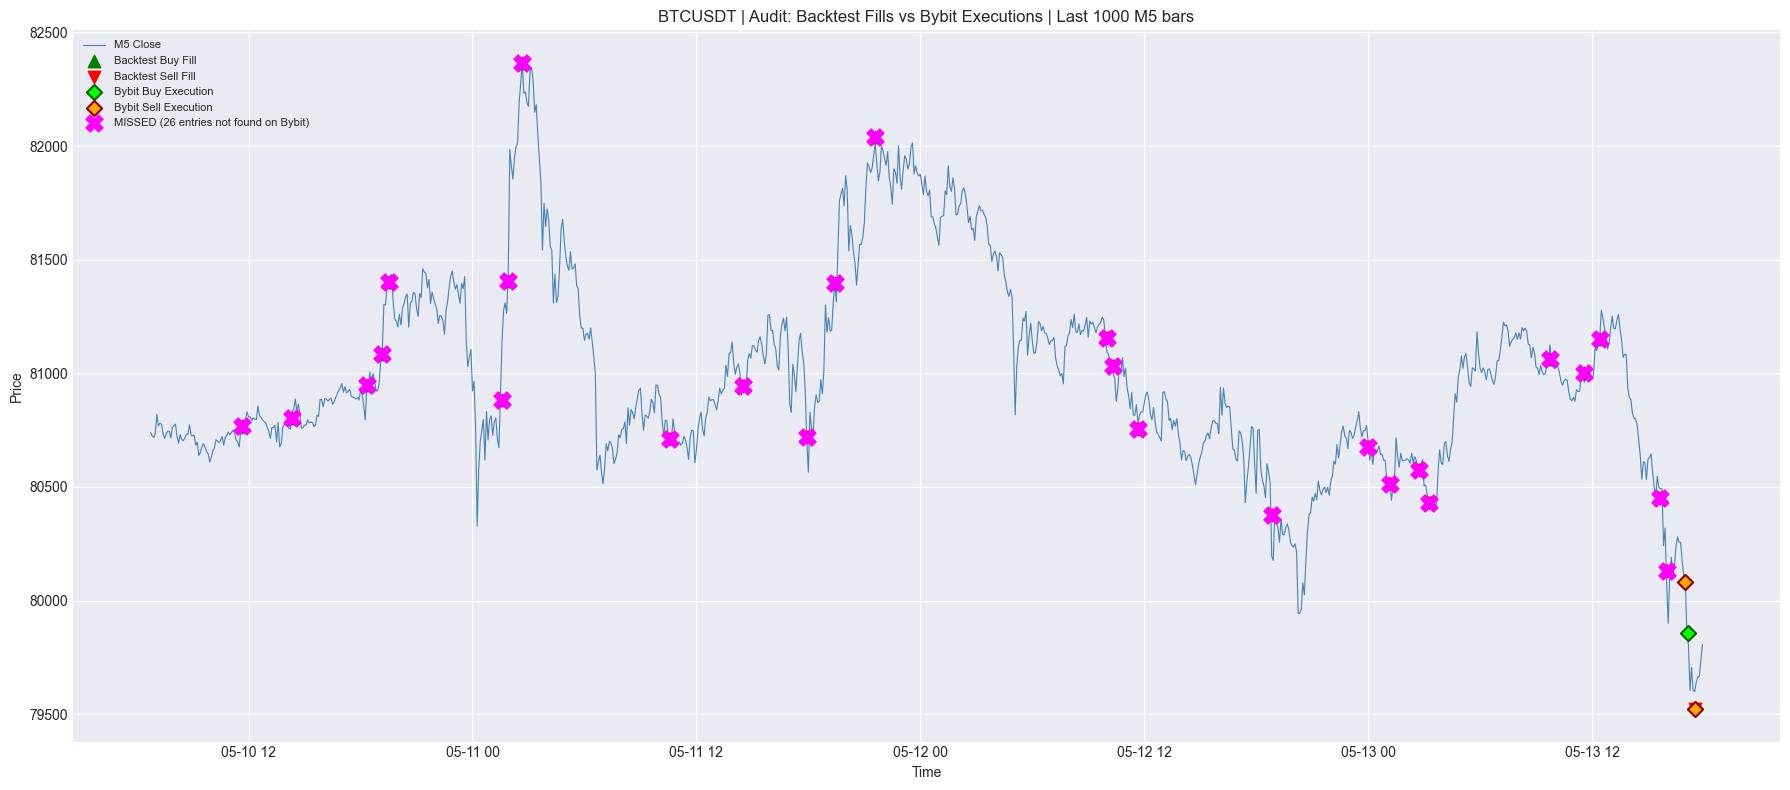

Audit chart saved -> results\audit\BTCUSDT\M5\audit_chart.png


In [105]:
# SECTION 11 — نمودار بصری: سیگنال‌های backtest vs اوردرهای Bybit

fig, ax = plt.subplots(figsize=(18, 8))

# قیمت M5
ax.plot(m5_ctx.index, m5_ctx["close"], color="steelblue", linewidth=0.8, label="M5 Close", zorder=1)

# ── Backtest fills ─────────────────────────────────────────────
if not entry_fills_df.empty:
    bt_buys  = entry_fills_df[entry_fills_df["side"] == "buy"]
    bt_sells = entry_fills_df[entry_fills_df["side"] == "sell"]

    ax.scatter(
        pd.to_datetime(bt_buys["entry_time"]), bt_buys["entry"],
        marker="^", color="green", s=80, zorder=3, label="Backtest Buy Fill"
    )
    ax.scatter(
        pd.to_datetime(bt_sells["entry_time"]), bt_sells["entry"],
        marker="v", color="red", s=80, zorder=3, label="Backtest Sell Fill"
    )

# ── Bybit executions ───────────────────────────────────────────
if not bybit_exec_df.empty and "execTime" in bybit_exec_df.columns:
    bybit_trade_fills = bybit_exec_df[
        bybit_exec_df.get("execType", pd.Series(["Trade"] * len(bybit_exec_df))) == "Trade"
    ] if "execType" in bybit_exec_df.columns else bybit_exec_df

    bybit_buy_fills  = bybit_trade_fills[bybit_trade_fills["side"] == "Buy"] if "side" in bybit_trade_fills.columns else pd.DataFrame()
    bybit_sell_fills = bybit_trade_fills[bybit_trade_fills["side"] == "Sell"] if "side" in bybit_trade_fills.columns else pd.DataFrame()

    if not bybit_buy_fills.empty:
        ax.scatter(
            bybit_buy_fills["execTime"], bybit_buy_fills["execPrice"],
            marker="D", color="lime", s=60, zorder=4, edgecolors="darkgreen",
            linewidths=1.5, label="Bybit Buy Execution"
        )
    if not bybit_sell_fills.empty:
        ax.scatter(
            bybit_sell_fills["execTime"], bybit_sell_fills["execPrice"],
            marker="D", color="orange", s=60, zorder=4, edgecolors="darkred",
            linewidths=1.5, label="Bybit Sell Execution"
        )

# ── Mismatches از audit ────────────────────────────────────────
if not audit_df.empty:
    missed = audit_df[audit_df["status"] == "NOT_FOUND"]
    if not missed.empty:
        ax.scatter(
            pd.to_datetime(missed["bt_entry_time"]), missed["bt_entry"],
            marker="X", color="magenta", s=150, zorder=5,
            label=f"MISSED ({len(missed)} entries not found on Bybit)"
        )

ax.set_title(f"{SYMBOL} | Audit: Backtest Fills vs Bybit Executions | Last {BARS_M5} M5 bars")
ax.set_ylabel("Price")
ax.set_xlabel("Time")
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(RESULT_DIR / "audit_chart.png", dpi=120)
plt.show()

print(f"Audit chart saved -> {RESULT_DIR / 'audit_chart.png'}")